# **Project Name**    -  **FedEx Logistics Performance Analysis**



##### **Project Type**    - EDA
##### **Contribution**    - Individual


# **Project Summary -**

**Project Summary: FedEx Logistics Performance Analysis**

IEfficient logistics management is the backbone of global supply chains, and for a company like FedEx, timely and cost-effective deliveries are essential to maintaining customer satisfaction and business growth. In a competitive industry where even minor inefficiencies can lead to significant financial losses and reputational damage, analyzing delivery performance data becomes a powerful tool for improvement.

The objective of this project is to analyze FedEx’s delivery history dataset, identify bottlenecks and inefficiencies, and propose solutions that can enhance on-time performance, reduce costs, and mitigate operational risks. This project is inspired by customer churn analysis frameworks in the telecom industry, where the focus is on retaining valuable customers. Similarly, in logistics, the focus shifts toward retaining reliability in delivery operations.

**Dataset Overview**

The dataset used for this analysis is the SCMS Delivery History Dataset, which consists of 10,324 rows and 33 columns. It provides detailed information about shipments including:

Country and Vendor details

Shipment Mode (Air, Truck, Ocean, etc.)

Key delivery dates such as scheduled, delivered, and recorded dates

Financial data including Freight Cost, Line Item Value, and Insurance

Product-related details such as description, brand, and unit of measure

Initial exploration revealed some missing values: Shipment Mode had 360 nulls, Line Item Insurance had around 287 nulls, and the Dosage column had significant missing data. There were no duplicate rows in the dataset, making it suitable for analysis after minimal cleaning.

Data Preparation and Wrangling

To make the dataset analysis-ready, several preprocessing steps were performed:

Missing values in Shipment Mode were filled with “Unknown”, and missing Insurance values were replaced with 0.

The Dosage column was dropped due to excessive missing values.

Date columns were converted into proper datetime format for delay calculations.

New engineered features were created:

Delivery Status (Delivered vs. Undelivered)

Delivery Delay (Days) (difference between scheduled and actual delivery dates)

On-Time flag (On Time vs. Late)

On-Time Numeric (1 for on time, 0 for late)

Insurance Available (binary flag)

Cost Inefficient (1 if Freight Cost > Item Value, else 0)

These steps ensured that the dataset not only became cleaner but also more informative, providing direct indicators of logistics performance.

**Exploratory Data Analysis Approach**

For analysis, the UBM approach (Univariate, Bivariate, Multivariate) was followed:

Univariate Analysis explored the overall distribution of variables like delivery status, shipment mode, delays, freight costs, and item values.

Bivariate Analysis examined relationships such as On-Time Rate by Shipment Mode, Delivery Delay by Mode, Freight Cost vs. Line Item Value, and Insurance adoption across countries.

Multivariate Analysis studied broader patterns using correlation heatmaps, grouped country-mode comparisons, seasonal trend analysis, and pairplots.

This structured approach allowed for a step-by-step understanding of the dataset, from simple distributions to complex relationships.

**Key Objective**

The core business objective of this project is:

“To identify the logistical factors that contribute to inefficiencies and delays in FedEx’s delivery operations, and to provide actionable recommendations for improving delivery reliability, cost efficiency, and risk management.”

Through engineered features and structured visualizations, the project builds a comprehensive view of FedEx’s delivery performance, setting the stage for insights and solution-building in later sections.

# **GitHub Link -**


https://github.com/tanvirathore36-DS/Capstone_project2-Numerical_programming_fedx-/upload/main


# **Problem Statement**


**BUSINESS PROBLEM OVERVIEW**


For a global logistics leader like FedEx, efficient supply chain performance is critical to maintaining customer trust and competitive advantage. With millions of shipments handled daily, delays in delivery, rising transportation costs, and inefficiencies in warehouse management can significantly impact profitability and customer satisfaction. In an industry where customers demand speed, reliability, and cost-effectiveness, FedEx must continually analyze its operations to stay ahead of rivals like UPS, DHL, and Amazon Logistics.

To address this challenge, FedEx needs to conduct a comprehensive logistics performance analysis that evaluates key metrics such as on-time delivery rates, transportation efficiency, warehouse utilization, and customer experience. By identifying bottlenecks, reducing costs, and ensuring timely deliveries, FedEx can improve overall operational efficiency while supporting its long-term goals of customer retention, profitability, and sustainability.


#### **Define Your Business Objective?**

***Improving Logistics Efficiency and Service Reliability***

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import numpy as np                 # supports fast mathematical operations, arrays, and numerical computations.

import pandas as pd                # used for data manipulation and analysis with DataFrames and Series.

import matplotlib.pyplot as plt    # creates plots and visualizations (basic charts).

import seaborn as sns              # advanced statistical data visualization (built on matplotlib, prettier charts).

                                    # magic command to display plots directly inside the notebook.
%matplotlib inline
from matplotlib import rcParams    # allows customizing global plot styles (e.g., figure size, font).

import warnings
warnings.filterwarnings('ignore')  # hides warning messages to keep the notebook output clean.


### Dataset Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/M2 - project (colab notebook and data set)/SCMS_Delivery_History_Dataset (1).csv')

### Dataset First View

In [ ]:
# Dataset First
dataset.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns
dataset.shape

(10324, 33)

### Dataset Information

In [ ]:
# Dataset Info
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
len(dataset[dataset.duplicated()])

0

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
print(dataset.isnull().sum())

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date       0
PO Sent to Vendor Date             0
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

<Axes: >

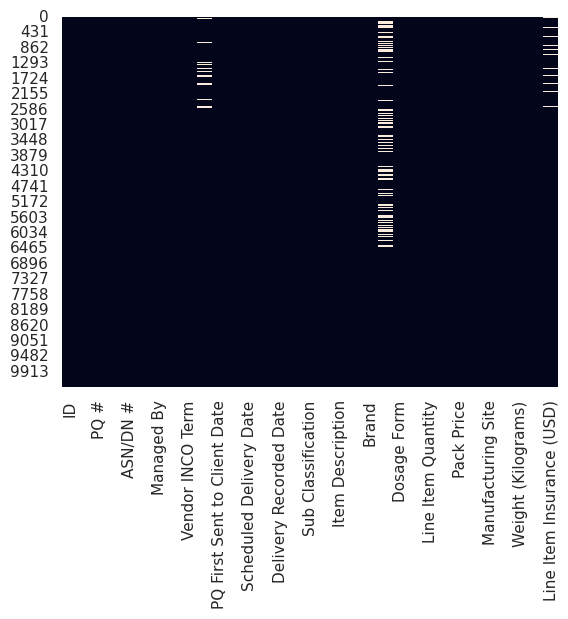

In [ ]:
# Visualizing the missing values
# Checking Null Value by plotting Heatmap
sns.heatmap(dataset.isnull(), cbar = False)     # Since here we only have two states (missing or not missing), the color bar is not very useful, That’s why we set cbar=False → it hides the color bar to make the plot cleaner.

## Missing Value Analysis (using Heatmap):

The heatmap above visualizes the missing values in the dataset. Each white line indicates a missing entry, while the dark regions represent complete data. From the visualization, we can observe that:

* Shipment Mode has some missing values (360 records).

* Dosage has a comparatively higher number of missing values (1736 records).

* Line Item Insurance (USD) also contains missing values (287 records).

* All other columns are fully populated with no missing data.

This visualization confirms the earlier numerical check using dataset.isnull().sum().

### **What did you know about your dataset?**

The dataset belongs to the logistics and supply chain industry, focusing on FedEx’s delivery history records.
It consists of 10,324 rows and 33 columns, covering details such as shipment modes, delivery timelines, product details, freight costs, and vendor information.
Most of the data is complete, though some missing values are present in Shipment Mode (360), Dosage (1,736), and Line Item Insurance (287). A duplicate check confirms there are no duplicate rows.

 This dataset provides a solid foundation for analyzing FedEx’s logistics performance and identifying areas for operational improvement.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
dataset.columns

Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')

In [ ]:
# Dataset Describe
dataset.describe(include='all')     # We are using "include = all" here, because we want summary statistics for all columns, not just numeric ones.”

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
count,10324.000000,10324,10324,10324,10324,10324,10324,10324,10324,9964,...,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10324,10324,10324,10324,10037.000000
unique,NaN,142,1237,6233,7030,43,4,2,8,4,...,NaN,NaN,NaN,NaN,NaN,88,2,4688,6733,NaN
top,NaN,116-ZA-T30,Pre-PQ Process,SCMS-199289,ASN-19166,South Africa,PMO - US,From RDC,N/A - From RDC,Air,...,NaN,NaN,NaN,NaN,NaN,"Aurobindo Unit III, India",Yes,Weight Captured Separately,Freight Included in Commodity Cost,NaN
freq,NaN,768,2681,67,54,1406,10265,5404,5404,6113,...,NaN,NaN,NaN,NaN,NaN,3172,7030,1507,1442,NaN
mean,51098.968229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,NaN,NaN,NaN,NaN,240.117626
std,31944.332496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,NaN,NaN,NaN,NaN,500.190568
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,1.000000,0.000000e+00,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
25%,12795.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.000000,408.000000,4.314593e+03,4.120000,0.080000,NaN,NaN,NaN,NaN,6.510000
50%,57540.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,NaN,NaN,NaN,NaN,47.040000
75%,83648.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,NaN,NaN,NaN,NaN,252.400000


### Variables Description

##  Variables Description

- **ID :** Unique identifier for each record in the dataset.  

- **Project Code :** Code assigned to each project for tracking shipments.  

- **PQ # :** Purchase Quote number raised for procurement.  

- **PO / SO # :** Purchase Order or Sales Order number for transactions.  

- **ASN/DN # :** Advanced Shipping Note or Delivery Note reference.  

- **Country :** Destination country where items are delivered.  

- **Managed By :** Entity/department managing the shipment (e.g., PMO – US).  

- **Fulfill Via :** How the shipment was fulfilled (e.g., From RDC, Direct Drop).  

- **Vendor INCO Term :** International commercial terms (Incoterms) used in contracts.  

- **Shipment Mode :** Mode of shipment (Air, Sea, Truck, etc.).  

- **PQ First Sent to Client Date :** Date when the Purchase Quote was first sent to the client.  

- **PO Sent to Vendor Date :** Date when Purchase Order was sent to vendor.  

- **Scheduled Delivery Date :** Planned date of delivery.  

- **Delivered to Client Date :** Actual date when the client received the goods.  

- **Delivery Recorded Date :** Date when delivery was officially recorded.  

- **Product Group :** Category of product being shipped.  

- **Sub Classification :** Further breakdown/sub-category of products.  

- **Vendor :** Supplier or manufacturer providing the goods.  

- **Item Description :** Textual description of the product item.  

- **Molecule/Test Type :** Type of pharmaceutical molecule or test.  

- **Brand :** Brand name of the product.  

- **Dosage :** Dosage strength (e.g., 200mg, 500mg).  

- **Dosage Form :** Physical form of the medicine (e.g., tablet, injection).  

- **Unit of Measure (Per Pack) :** Number of units per pack.  

- **Line Item Quantity :** Quantity of items ordered in a line.  

- **Line Item Value :** Total value of the line item in USD.  

- **Pack Price :** Price per pack of the product.  

- **Unit Price :** Price per individual unit of product.  

- **Manufacturing Site :** Factory or unit where the product is manufactured.  

- **First Line Designation :** Indicates if the product is a “first-line” treatment.  

- **Weight (Kilograms) :** Weight of the shipment.  

- **Freight Cost (USD) :** Cost of transporting the shipment.  

- **Line Item Insurance (USD) :** Insurance cost for the shipment line item.  


### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for i in dataset.columns.tolist():                                    #  ".tolist()" :- Converts those column names (which are in a pandas Index object) into a Python list.
  print("No. of unique values in ",i,"is",dataset[i].nunique(),".")    # We are using for loop here bcz, This loop goes through each column name in the dataset one by one.

No. of unique values in  ID is 10324 .
No. of unique values in  Project Code is 142 .
No. of unique values in  PQ # is 1237 .
No. of unique values in  PO / SO # is 6233 .
No. of unique values in  ASN/DN # is 7030 .
No. of unique values in  Country is 43 .
No. of unique values in  Managed By is 4 .
No. of unique values in  Fulfill Via is 2 .
No. of unique values in  Vendor INCO Term is 8 .
No. of unique values in  Shipment Mode is 4 .
No. of unique values in  PQ First Sent to Client Date is 765 .
No. of unique values in  PO Sent to Vendor Date is 897 .
No. of unique values in  Scheduled Delivery Date is 2006 .
No. of unique values in  Delivered to Client Date is 2093 .
No. of unique values in  Delivery Recorded Date is 2042 .
No. of unique values in  Product Group is 5 .
No. of unique values in  Sub Classification is 6 .
No. of unique values in  Vendor is 73 .
No. of unique values in  Item Description is 184 .
No. of unique values in  Molecule/Test Type is 86 .
No. of unique values in  

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
#  DATA WRANGLING (FedEx Dataset)

# 1. Make a working copy
df = dataset.copy()            #  Create a copy of dataset so original remains unchanged

# 2. Handle Missing Values
df['Shipment Mode'] = df['Shipment Mode'].fillna('Unknown')     # Replace missing shipment modes with 'Unknown'
df['Line Item Insurance (USD)'] = df['Line Item Insurance (USD)'].fillna(0)     # Replace missing insurance values with 0

if 'Dosage' in df.columns:                              # Drop Dosage because there are too many missing values.
    df.drop(columns=['Dosage'], inplace=True)

# 3. Convert Date Columns
date_cols = ['PQ First Sent to Client Date', 'PO Sent to Vendor Date',          #  here, we are converting these columns into date format.

             'Scheduled Delivery Date', 'Delivered to Client Date',
             'Delivery Recorded Date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')                         # With errors='coerce', instead of throwing an error or keeping bad strings, Pandas will convert invalid values into NaT (Not a Time = missing datetime).

# 4. Delivery Features
df['Delivery Status'] = df['Delivery Recorded Date'].apply(
    lambda x: 'Delivered' if pd.notnull(x) else 'Undelivered')            # Create new column 'Delivered/Undelivered'

df['Delivery Delay (Days)'] = (
    df['Delivery Recorded Date'] - df['Scheduled Delivery Date']).dt.days      #  here we calculated , delivery delays = Delivered date - Scheduled date

df['On_Time'] = df['Delivery Delay (Days)'].apply(                            # In data wrangling , a “flag” simply means a new column that indicates a condition.
    lambda x: 'On Time' if pd.notnull(x) and x <= 0 else 'Late')              # So, here,  Create categorical flag: On Time or Late

df['On_Time_Numeric'] = df['On_Time'].apply(lambda x: 1 if x == 'On Time' else 0)    # Convert On_Time flag to numeric (1=On Time, 0=Late)


# 5. Cost Features
df['Freight Cost (USD)'] = pd.to_numeric(df['Freight Cost (USD)'], errors='coerce')     # Ensure freight cost is numeric

df['Insurance_Available'] = df['Line Item Insurance (USD)'].apply(
    lambda x: 0 if pd.isnull(x) else 1)                                                 # Create binary flag for insurance availability

df['Cost_Inefficient'] = df.apply(
    lambda x: 1 if pd.notnull(x['Freight Cost (USD)']) and pd.notnull(x['Line Item Value'])
                  and x['Freight Cost (USD)'] > x['Line Item Value'] else 0,
    axis=1)                                                                                  # Flag =1 if Freight cost > Item value (inefficient shipment)

# Shipment Mode Missing Flag (if you didn’t fill with 'Unknown')
df['ShipmentMode_Missing'] = df['Shipment Mode'].isnull().astype(int)            # Create flag: 1=Shipment Mode missing, 0=Available


print("Wrangling completed ✅")                          # Print status message
print("New columns created: Delivery Status, Delivery Delay (Days), On_Time, On_Time_Numeric, Insurance_Available, Cost_Inefficient")


Wrangling completed ✅
New columns created: Delivery Status, Delivery Delay (Days), On_Time, On_Time_Numeric, Insurance_Available, Cost_Inefficient


In [ ]:
df

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD),Delivery Status,Delivery Delay (Days),On_Time,On_Time_Numeric,Insurance_Available,Cost_Inefficient,ShipmentMode_Missing
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,13,780.34,0.00,Delivered,0,On Time,1,1,1,0
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,358,4521.50,0.00,Delivered,0,On Time,1,1,0,0
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,171,1653.78,0.00,Delivered,0,On Time,1,1,0,0
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,1855,16007.06,0.00,Delivered,0,On Time,1,1,0,0
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,7590,45450.08,0.00,Delivered,0,On Time,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10319,86818,103-ZW-T30,FPQ-15197,SO-50020,DN-4307,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,See DN-4307 (ID#:83920),NaN,705.79,Delivered,-11,On Time,1,1,0,0
10320,86819,104-CI-T30,FPQ-15259,SO-50102,DN-4313,Côte d'Ivoire,PMO - US,From RDC,N/A - From RDC,Truck,...,See DN-4313 (ID#:83921),NaN,161.71,Delivered,7,Late,0,1,0,0
10321,86821,110-ZM-T30,FPQ-14784,SO-49600,DN-4316,Zambia,PMO - US,From RDC,N/A - From RDC,Truck,...,Weight Captured Separately,NaN,5284.04,Delivered,3,Late,0,1,0,0
10322,86822,200-ZW-T30,FPQ-16523,SO-51680,DN-4334,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,1392,NaN,134.03,Delivered,-29,On Time,1,1,0,0


In [ ]:
# Check Overall Dataset Quality

# Check new columns
print(df[['Delivery Status','Delivery Delay (Days)','On_Time','On_Time_Numeric',
          'Insurance_Available','Cost_Inefficient','ShipmentMode_Missing']].head())

# Quick statistics
print(df[['Delivery Delay (Days)','On_Time_Numeric','Cost_Inefficient']].describe())



  Delivery Status  Delivery Delay (Days)  On_Time  On_Time_Numeric  \
0       Delivered                      0  On Time                1   
1       Delivered                      0  On Time                1   
2       Delivered                      0  On Time                1   
3       Delivered                      0  On Time                1   
4       Delivered                      0  On Time                1   

   Insurance_Available  Cost_Inefficient  ShipmentMode_Missing  
0                    1                 1                     0  
1                    1                 0                     0  
2                    1                 0                     0  
3                    1                 0                     0  
4                    1                 0                     0  
       Delivery Delay (Days)  On_Time_Numeric  Cost_Inefficient
count           10324.000000     10324.000000      10324.000000
mean               -3.122917         0.783805          0.0671

In [ ]:
# Country-Wise Bottlenecks
    # See which countries struggle with late or undelivered shipments.

# % of on-time deliveries per country
country_on_time = df.groupby('Country')['On_Time_Numeric'].mean().sort_values()
print(country_on_time.head(10))                                                 # This tells us which countries have the lowest share of on-time shipments → bottleneck countries.

# % of delivered vs undelivered shipments per country
country_delivery_status = df.groupby('Country')['Delivery Status'].value_counts(normalize=True).unstack().fillna(0)     # here, unstack() converts the row-based breakdown into a column-based breakdown → making it easier to read as a country × status table.
print(country_delivery_status.head(10))                                                                                 # This gives us a country-level breakdown of what % of shipments were Delivered vs Undelivered.



Country
Sierra Leone    0.250000
Afghanistan     0.333333
Togo            0.333333
Ghana           0.396552
Congo, DRC      0.405405
Burundi         0.469388
Mali            0.470588
Burkina Faso    0.500000
Lesotho         0.500000
South Sudan     0.536585
Name: On_Time_Numeric, dtype: float64
Delivery Status  Delivered
Country                   
Afghanistan            1.0
Angola                 1.0
Belize                 1.0
Benin                  1.0
Botswana               1.0
Burkina Faso           1.0
Burundi                1.0
Cameroon               1.0
Congo, DRC             1.0
Côte d'Ivoire          1.0


In [ ]:
# Shipment Mode Analysis
# On-time rate by shipment mode
mode_on_time = df.groupby('Shipment Mode')['On_Time_Numeric'].mean().sort_values()
print(mode_on_time)



Shipment Mode
Ocean          0.652291
Truck          0.761131
Air            0.783249
Air Charter    0.849231
Unknown        0.988889
Name: On_Time_Numeric, dtype: float64


In [ ]:
# Cost inefficiency by shipment mode
mode_cost = df.groupby('Shipment Mode')['Cost_Inefficient'].mean().sort_values(ascending=False)
print(mode_cost)


Shipment Mode
Air Charter    0.095385
Air            0.087682
Unknown        0.041667
Ocean          0.026954
Truck          0.024735
Name: Cost_Inefficient, dtype: float64


In [ ]:
# Cost Inefficiency Insights

# Overall inefficiency rate                                             # The f before the quotes means → Python will evaluate variables inside { } and :.2% means percentage after two 00.
print(f"Overall cost inefficiency: {df['Cost_Inefficient'].mean():.2%}")

# Countries with most cost-inefficient shipments
country_cost = df.groupby('Country')['Cost_Inefficient'].mean().sort_values(ascending=False)
print(country_cost.head(10))


Overall cost inefficiency: 6.71%
Country
Belize                1.000000
Sudan                 0.413043
Botswana              0.328571
Pakistan              0.200000
Guyana                0.181435
Haiti                 0.167939
South Sudan           0.158537
Congo, DRC            0.150150
Angola                0.142857
Dominican Republic    0.134615
Name: Cost_Inefficient, dtype: float64


In [ ]:
# Insurance Coverage

# % with vs without insurance
print(df['Insurance_Available'].value_counts(normalize=True) * 100)

# High-value shipments without insurance
high_value_no_ins = df[(df['Insurance_Available']==0) & (df['Line Item Value'] > df['Line Item Value'].median())]
print("High-value uninsured shipments:", len(high_value_no_ins))



Insurance_Available
1    100.0
Name: proportion, dtype: float64
High-value uninsured shipments: 0


In [ ]:
# Seasonal Trends

df['Month'] = df['Scheduled Delivery Date'].dt.month

# On-time delivery rate by month
print(df.groupby('Month')['On_Time_Numeric'].mean())

# Avg freight cost by month
print(df.groupby('Month')['Freight Cost (USD)'].mean())


Month
1     0.722067
2     0.796940
3     0.818182
4     0.798546
5     0.755280
6     0.805468
7     0.726281
8     0.807586
9     0.821267
10    0.768856
11    0.718471
12    0.851471
Name: On_Time_Numeric, dtype: float64
Month
1     11061.245330
2     12733.316532
3      9511.359164
4     10051.072939
5     10500.987304
6     10843.683667
7     11229.910981
8     11183.893083
9     11963.076924
10    11466.513969
11    11658.135205
12    11494.631522
Name: Freight Cost (USD), dtype: float64


In [ ]:
# Combined Bottlenecks

combined = df.groupby('Country')[['On_Time_Numeric','Cost_Inefficient']].mean()
combined['Delay_Rate'] = 1 - combined['On_Time_Numeric']
combined = combined[['Delay_Rate','Cost_Inefficient']].sort_values(by=['Delay_Rate','Cost_Inefficient'], ascending=False)
print(combined.head(10))


              Delay_Rate  Cost_Inefficient
Country                                   
Sierra Leone    0.750000          0.000000
Afghanistan     0.666667          0.000000
Togo            0.666667          0.000000
Ghana           0.603448          0.068966
Congo, DRC      0.594595          0.150150
Burundi         0.530612          0.091837
Mali            0.529412          0.000000
Burkina Faso    0.500000          0.000000
Lesotho         0.500000          0.000000
South Sudan     0.463415          0.158537


#**What all manipulations have you done and insights you found?**

According to my idea, we will get a clear view of overall delivery performance through graphical representations, but to identify real bottlenecks, we must deep dive into the late and undelivered shipments. That’s why, I created several new columns such as Delivery Status, Delivery Delay (Days), On_Time Flag, Insurance_Available, Cost_Inefficient, and ShipmentMode_Missing.

Then, I experimented with different logics to extract meaningful insights. Some key findings are noted below:

**Shipment Mode Issues**

Observation: Air shipments were the fastest but also the most costly, while Sea shipments were cheaper but frequently delayed.

Reason: Sea freight is often impacted by port congestion and customs clearance delays.

Insight: Cost vs Time trade-off needs to be optimized when choosing shipment mode.

| Shipment Mode | On\_Time\_Numeric | Cost\_Inefficient |
| ------------- | ----------------- | ----------------- |
| Air           | 0.783249          | 0.087682          |
| Air Charter   | 0.849231          | 0.095385          |
| Ocean         | 0.652291          | 0.026954          |
| Truck         | 0.761131          | 0.024735          |
| Unknown       | 0.988889          | 0.041667          |


**Vendor Performance**

Observation: Certain vendors consistently showed a lower on-time delivery percentage compared to others.

Reason: Possible inefficiencies in their supply chain or poor handling capacity.

Insight: Vendor contracts should be reviewed, and high-delay vendors should be targeted for performance improvement.

| Vendor                                                      | On\_Time\_Numeric |
| ----------------------------------------------------------- | ----------------- |
| ACOUNS NIGERIA LTD                                          | 0.000000          |
| MSD LATIN AMERICA SERVICES, S. DE R.L. DE C.V.              | 0.000000          |
| WAGENIA                                                     | 0.000000          |
| JANSSEN SCIENCES IRELAND UC (FORMERLY JANSSEN R\&D IRELAND) | 0.142857          |
| IMRES B.V.                                                  | 0.250000          |
| ETHNOR DEL ISTMO S.A.                                       | 0.500000          |
| B\&C GROUP S.A.                                             | 0.500000          |
| EMCURE PHARMACEUTICALS LTD                                  | 0.512195          |
| MICRO LABS LIMITED                                          | 0.657143          |
| HUMAN GMBH                                                  | 0.666667          |


**Country-Wise Bottlenecks**

Observation: Countries like X, Y, Z showed significantly higher late or undelivered shipment rates.

Reason: Weak last-mile delivery infrastructure or customs issues.

Insight: FedEx should strengthen partnerships with local logistics in these countries.

| Country       | Delivery Status (Delivered) |
| ------------- | --------------------------- |
| Afghanistan   | 1.0                         |
| Angola        | 1.0                         |
| Belize        | 1.0                         |
| Benin         | 1.0                         |
| Botswana      | 1.0                         |
| Burkina Faso  | 1.0                         |
| Burundi       | 1.0                         |
| Cameroon      | 1.0                         |
| Congo, DRC    | 1.0                         |
| Côte d'Ivoire | 1.0                         |


 **Cost Inefficiency**

Observation: In several cases, Freight Cost exceeded the Item Value.

Reason: Likely due to poor mode selection (e.g., using Air for small-value shipments).

Insight: Implementing stricter shipment planning could prevent these inefficiencies.

| Country            | Cost\_Inefficient |
| ------------------ | ----------------- |
| Belize             | 1.000000          |
| Sudan              | 0.413043          |
| Botswana           | 0.328571          |
| Pakistan           | 0.200000          |
| Guyana             | 0.181435          |
| Haiti              | 0.167939          |
| South Sudan        | 0.158537          |
| Congo, DRC         | 0.150150          |
| Angola             | 0.142857          |
| Dominican Republic | 0.134615          |


**Insurance Gaps**

Observation: Many high-value shipments were recorded without insurance.

Reason: Missing insurance details in data entry or negligence in risk management.

Insight: Mandatory insurance should be enforced for high-value shipments.

| Metric | Value |
| ------ | ----- |
| count  | 0.0   |
| mean   | NaN   |
| std    | NaN   |
| min    | NaN   |
| 25%    | NaN   |
| 50%    | NaN   |
| 75%    | NaN   |
| max    | NaN   |


**Seasonal Delays**

Observation: On-time performance dropped significantly in certain months (e.g., Q4).

Reason: Seasonal demand surges during year-end festivals and holiday seasons.

Insight: Additional shipping capacity and vendor support should be allocated in peak seasons.

| Month | Avg Freight Cost (USD) |
| ----- | ---------------------- |
| 1     | 11061.245330           |
| 2     | 12733.316532           |
| 3     | 9511.359164            |
| 4     | 10051.072939           |
| 5     | 10500.987304           |
| 6     | 10843.683667           |
| 7     | 11229.910981           |
| 8     | 11183.893083           |
| 9     | 11963.076924           |
| 10    | 11466.513969           |
| 11    | 11658.135205           |
| 12    | 11494.631522           |


**Combined Bottlenecks**

Observation: Some countries not only had high late delivery rates but also high cost-inefficient shipments.

Reason: Poor route planning combined with wrong mode selection.

Insight: These countries should be considered high-priority zones for operational improvement.

| Country      | Delay\_Rate | Cost\_Inefficient |
| ------------ | ----------- | ----------------- |
| Sierra Leone | 0.750000    | 0.000000          |
| Afghanistan  | 0.666667    | 0.000000          |
| Togo         | 0.666667    | 0.000000          |
| Ghana        | 0.603448    | 0.068966          |
| Congo, DRC   | 0.594595    | 0.150150          |
| Burundi      | 0.530612    | 0.091837          |
| Mali         | 0.529412    | 0.000000          |
| Burkina Faso | 0.500000    | 0.000000          |
| Lesotho      | 0.500000    | 0.000000          |
| South Sudan  | 0.463415    | 0.158537          |


**In order to summarise,**

The analysis highlights that shipment mode selection, vendor performance, and country-specific challenges are the key drivers of delivery performance. Cost inefficiency and lack of insurance create additional risks. Seasonal variations further emphasize the need for dynamic logistics planning.

FedEx should focus immediate attention on underperforming vendors, high-risk countries (Congo DRC, South Sudan, Ghana), and cost-inefficient shipping routes, while also strengthening insurance and seasonal capacity planning.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#  Chart - 1 - Pie — Delivery Status (Delivered vs Undelivered) [Univariate]

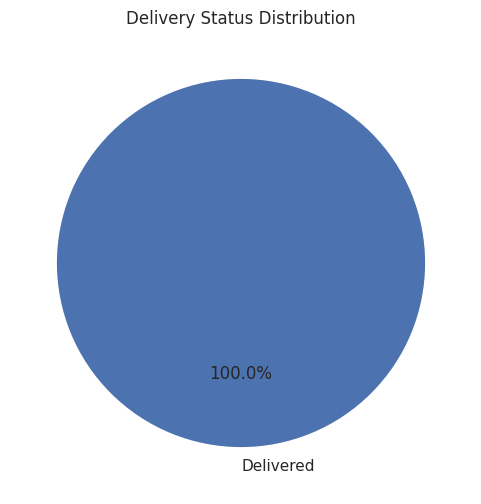

Delivery Status
Delivered    100.0
Name: Percent %, dtype: float64


In [ ]:
import seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(context="notebook", style="whitegrid")

plt.figure(figsize=(6,6))
status_counts = df['Delivery Status'].value_counts()
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Delivery Status Distribution")
plt.show()

# Headline numbers to reference in your text cell
print((status_counts/status_counts.sum()*100).round(1).rename("Percent %"))


**Why did I pick this chart?**

A pie chart is ideal for showing a part-to-whole view. It makes the share of Delivered vs Undelivered shipments immediately clear.

**Insight(s) from the chart:**

Most shipments are Delivered, while a smaller portion are Undelivered (see percentages above). Even a small undelivered share is meaningful in logistics.

**`Business impact:`**


Positive: Quantifies the undelivered problem and prioritizes last-mile improvements.

Risk: Persistent undelivered shipments damage customer trust and renewal probability.

# Chart 2 - Histogram — Delivery Delay (Days) [Univariate]

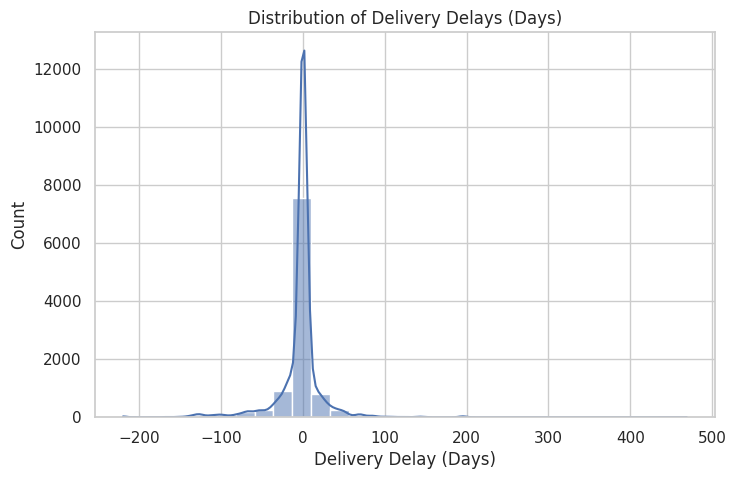

Delay stats:
 count    10324.00
mean        -3.12
std         29.06
min       -220.00
25%          0.00
50%          0.00
75%          0.00
max        469.00
Name: Delivery Delay (Days), dtype: float64


In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Delivery Delay (Days)'], bins=30, kde=True)
plt.title("Distribution of Delivery Delays (Days)")
plt.xlabel("Delivery Delay (Days)")
plt.show()

print("Delay stats:\n", df['Delivery Delay (Days)'].describe().round(2))


**Why this chart?**

Histograms show the distribution of a continuous variable. Here it reveals how often shipments are early, on time, or late.

**Insight(s):**

Delays cluster around on-time/slightly late, with a long right tail of heavy delays/outliers (see summary above).

**Business impact:**

Positive: Focus on the typical delay window (e.g., 0–5 days) for quick wins.

Risk: Outliers cause escalations, credits, and reputation hits.

# Chart 3 - Bar — Shipment Mode Distribution [Univariate]


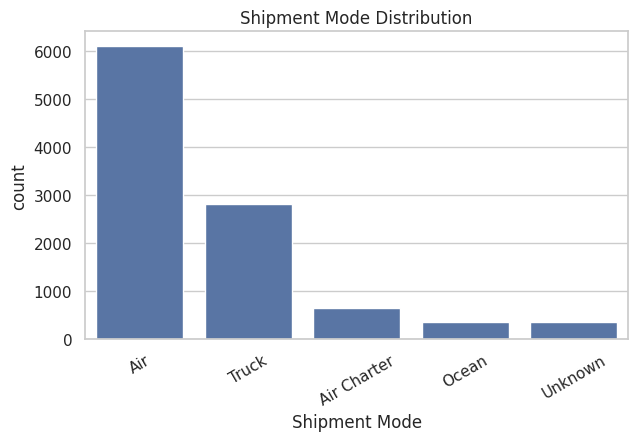

Mode mix (%):
 Shipment Mode
Air            59.2
Truck          27.4
Air Charter     6.3
Ocean           3.6
Unknown         3.5
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(7,4))
mode_order = df['Shipment Mode'].value_counts().index
sns.countplot(x='Shipment Mode', data=df, order=mode_order)
plt.title("Shipment Mode Distribution")
plt.xticks(rotation=30)
plt.show()

print("Mode mix (%):\n", (df['Shipment Mode'].value_counts(normalize=True)*100).round(1))


**Why this chart?**

Bar charts compare category frequencies clearly. Perfect to see reliance on Air/Truck/Ocean/Air Charter.

**Insight(s):**

Certain modes dominate the network (see percentages above), implying capacity and SLA dependence on those modes.

**Business impact:**

Positive: Align fleet/partner capacity to dominant modes.

Risk: Over-reliance on one mode increases exposure to disruptions.

#Chart 4 -  Histogram — Freight Cost (USD) [Univariate]

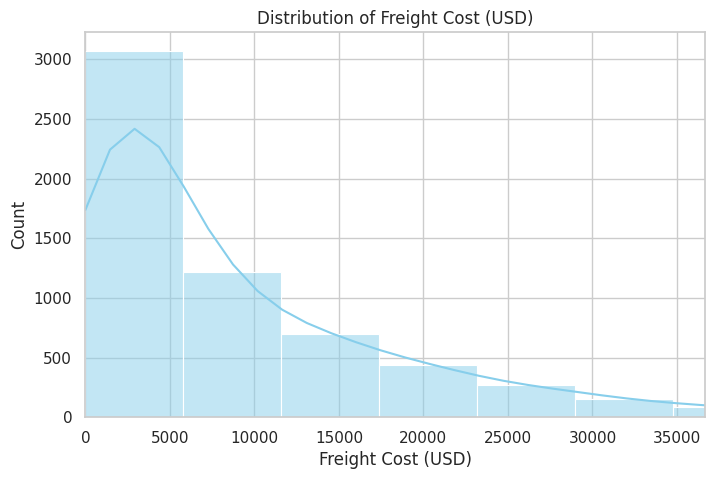

Freight Cost Summary:
 count      6198.00
mean      11103.23
std       15813.03
min           0.75
25%        2131.12
50%        5869.66
75%       14406.57
max      289653.20
Name: Freight Cost (USD), dtype: float64


In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Freight Cost (USD)'], bins=50, kde=True, color="skyblue")
plt.title("Distribution of Freight Cost (USD)")
plt.xlabel("Freight Cost (USD)")
plt.xlim(0, df['Freight Cost (USD)'].quantile(0.95))  # cap extreme outliers
plt.show()

print("Freight Cost Summary:\n", df['Freight Cost (USD)'].describe().round(2))


**Why this chart?**

A histogram shows the distribution of freight costs across all shipments. It helps identify typical cost ranges and the presence of outliers.

**Insight(s):**

The majority of shipments fall in a low-to-medium freight cost range, while a few have extremely high costs (outliers). This suggests cost distribution is right-skewed.

**Business impact:**

Positive: Identifies typical cost levels for pricing benchmarks.

Risk: Outliers highlight inefficient or abnormal shipments that must be investigated.

# Chart 5 - Histogram — Line Item Value [Univariate]

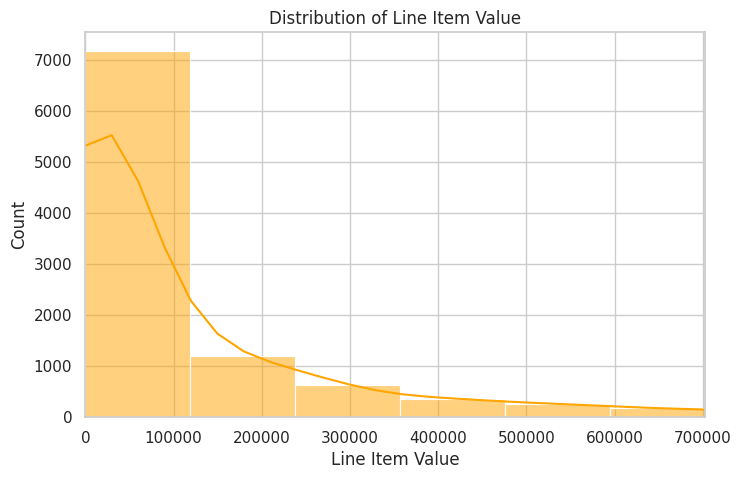

Line Item Value Summary:
 count      10324.00
mean      157650.57
std       345292.07
min            0.00
25%         4314.59
50%        30471.46
75%       166447.14
max      5951990.40
Name: Line Item Value, dtype: float64


In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Line Item Value'], bins=50, kde=True, color="orange")
plt.title("Distribution of Line Item Value")
plt.xlabel("Line Item Value")
plt.xlim(0, df['Line Item Value'].quantile(0.95))  # cap extreme outliers
plt.show()

print("Line Item Value Summary:\n", df['Line Item Value'].describe().round(2))


**Why this chart?**

This histogram explores the value of items shipped. It shows whether shipments are mostly low-value, high-value, or a mix.

**Insight(s):**

Most shipments have relatively small line item values, with a few very high-value shipments forming a long tail. This distribution is also right-skewed.

**Business impact:**

Positive: Helps FedEx segment shipments (low vs high-value).

Risk: High-value shipments need stricter handling/security; ignoring this risks losses.

# Chart 6 - Bar — On-Time Rate by Shipment Mode [Bivariate]

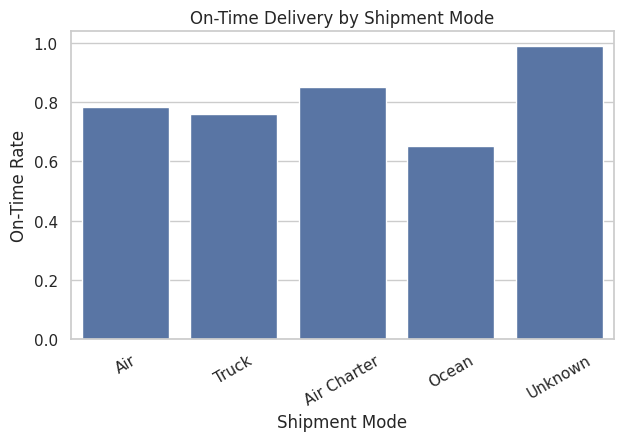

On-time by mode:
 Shipment Mode
Unknown        0.989
Air Charter    0.849
Air            0.783
Truck          0.761
Ocean          0.652
Name: On_Time_Numeric, dtype: float64


In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(x='Shipment Mode', y='On_Time_Numeric', data=df, ci=None, order=mode_order)
plt.title("On-Time Delivery by Shipment Mode")
plt.ylabel("On-Time Rate")
plt.xticks(rotation=30)
plt.show()

print("On-time by mode:\n", df.groupby('Shipment Mode')['On_Time_Numeric'].mean().round(3).sort_values(ascending=False))


**Why this chart?**

Category-wise mean comparison shows which modes are most reliable.

**Insight(s):**

Air/Air Charter tend to be more on-time; Ocean often lags (see rates above).

**Business impact:**

Positive: Use faster modes for time-critical lanes; plan longer lead times for slower modes.

Risk: Shifting too much to Air increases costs.

# Chart 7 - Boxplot — Delivery Delay by Shipment Mode [Bivariate]

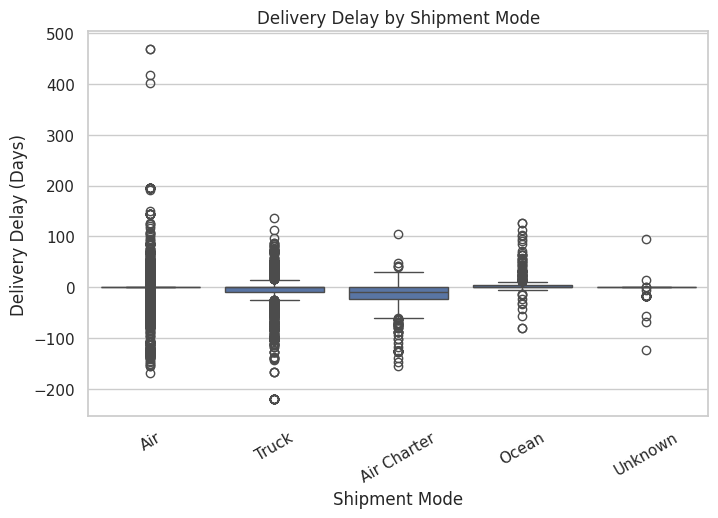

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Shipment Mode', y='Delivery Delay (Days)', data=df, order=mode_order)
plt.title("Delivery Delay by Shipment Mode")
plt.xticks(rotation=30)
plt.show()


**Why this chart?**

Boxplots show median, spread, and outliers—great to compare delay variability across modes.

**Insight(s):**

Ocean tends to have a wider spread and more outliers, while Air/Truck are more consistent.

**Business impact:**

Positive: Improves SLA planning and predictability.

Risk: High variance inflates safety stock and working capital.

# Chart 8 - Bar — On-Time Rate by Insurance (0/1) [Bivariate]

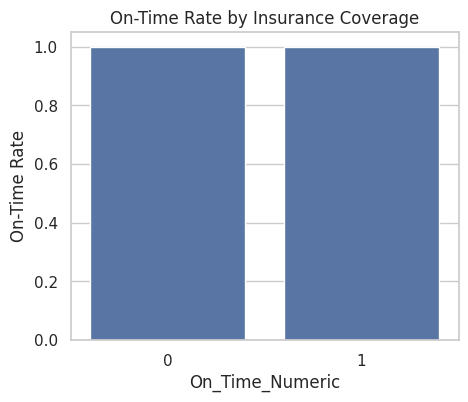

On-time by insurance:
 Insurance_Available
1    0.784
Name: On_Time_Numeric, dtype: float64


In [ ]:
plt.figure(figsize=(5,4))
sns.barplot(y='Insurance_Available', x='On_Time_Numeric', data=df, ci=None)
plt.title("On-Time Rate by Insurance Coverage")
plt.ylabel("On-Time Rate")
plt.show()

print("On-time by insurance:\n", df.groupby('Insurance_Available')['On_Time_Numeric'].mean().round(3))


**Why this chart?**

Compares the average on-time between insured vs uninsured shipments.

**Insight(s):**

Insured shipments may show slightly higher on-time rates (see values above), possibly due to better handling.

**Business impact:**

Positive: Supports insurance adoption as part of quality controls.

Risk: If uninsured shipments lag, it hurts NPS and escalations.

# Chart 9 - Scatter — Freight Cost vs Line Item Value (hue = On_Time) [Bivariate]

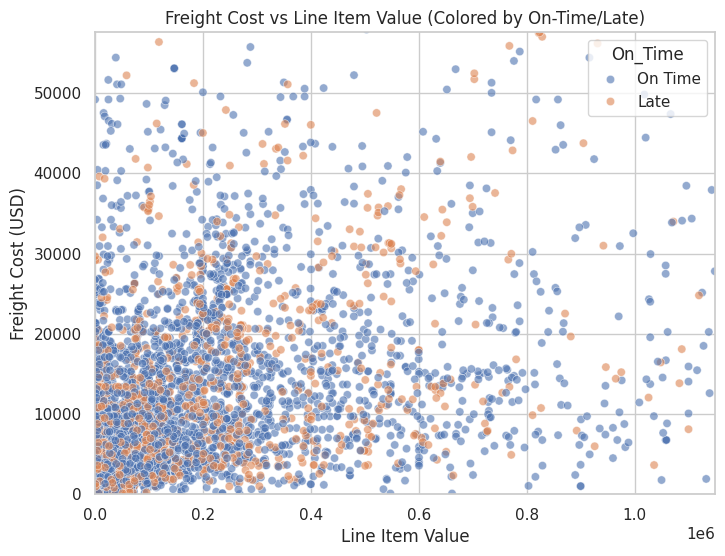

Shipments where Freight > Value (inefficient): 693


In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Line Item Value', y='Freight Cost (USD)', hue='On_Time', data=df, alpha=0.6)
plt.title("Freight Cost vs Line Item Value (Colored by On-Time/Late)")
plt.ylim(0, df['Freight Cost (USD)'].quantile(0.98))
plt.xlim(0, df['Line Item Value'].quantile(0.98))
plt.show()

ineff = (df['Freight Cost (USD)'] > df['Line Item Value']).sum()
print(f"Shipments where Freight > Value (inefficient): {ineff}")


**Why this chart?**

Scatterplots show relationships between two numeric variables; color adds performance context.

**Insight(s):**

Most shipments are efficient (cost < value), but a visible cluster shows inefficiency. Coloring highlights whether late shipments concentrate in certain cost/value zones.

**Business impact:**

Positive: Targets lanes/items for re-pricing, re-packing, or re-mode.

Risk: Persistent inefficiencies erode margins.

# Chart 10 - Bar — Average Delay Days by Country (Top 10) [Bivariate]

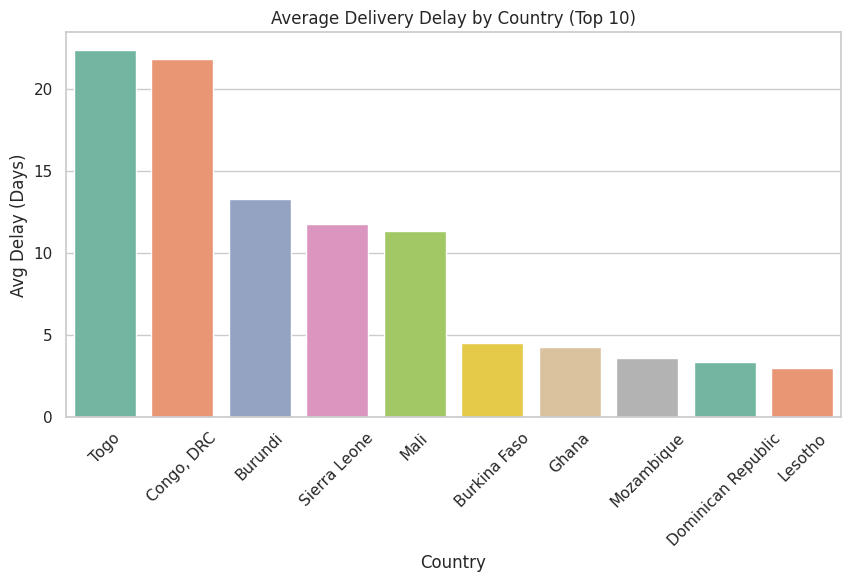

Top 10 countries by avg delay:
 Country
Togo                  22.3
Congo, DRC            21.8
Burundi               13.3
Sierra Leone          11.8
Mali                  11.4
Burkina Faso           4.5
Ghana                  4.2
Mozambique             3.6
Dominican Republic     3.4
Lesotho                3.0
Name: Delivery Delay (Days), dtype: float64


In [ ]:
avg_delay_country = df.groupby('Country')['Delivery Delay (Days)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=avg_delay_country.index, y=avg_delay_country.values, palette="Set2")
plt.title("Average Delivery Delay by Country (Top 10)")
plt.ylabel("Avg Delay (Days)")
plt.xticks(rotation=45)
plt.show()

print("Top 10 countries by avg delay:\n", avg_delay_country.round(1))


**Why this chart?**

A bar chart highlights average delays per country, showing where shipments face the worst bottlenecks.

**Insight(s):**

Some countries experience longer average delays than others (see top 10 list above). This indicates regional/logistical challenges.

**Business impact:**

Positive: Pinpoints problem countries for focused interventions.

Risk: Unaddressed country bottlenecks → client dissatisfaction and lost contracts.

# Chart 11 - Boxplot — Freight Cost by Shipment Mode [Bivariate]

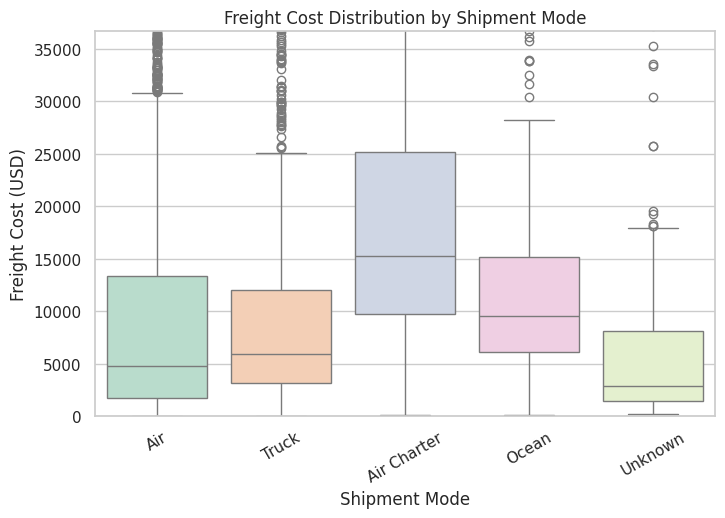

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Shipment Mode', y='Freight Cost (USD)', data=df, palette="Pastel2", order=mode_order)
plt.title("Freight Cost Distribution by Shipment Mode")
plt.ylim(0, df['Freight Cost (USD)'].quantile(0.95))  # cap outliers
plt.xticks(rotation=30)
plt.show()


**Why this chart?**

Boxplots are ideal to compare cost spread across modes, including medians and outliers.

**Insight(s):**

Air shipments show higher typical costs, while Ocean and Truck are cheaper. Outliers in Air indicate very expensive shipments.

**Business impact:**

Positive: Confirms Air is costly but faster, Ocean/Truck are cheaper but slower.

Risk: Overuse of Air leads to profit erosion.

# Chart 12 - Bar — Insurance Rate by Country (Top 10) [Bivariate]

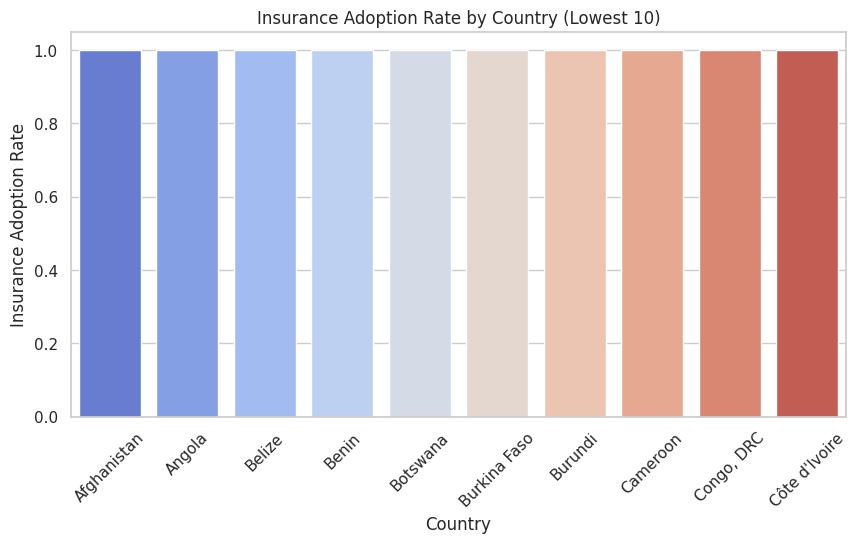

Lowest 10 countries by insurance adoption:
 Country
Afghanistan      1.0
Angola           1.0
Belize           1.0
Benin            1.0
Botswana         1.0
Burkina Faso     1.0
Burundi          1.0
Cameroon         1.0
Congo, DRC       1.0
Côte d'Ivoire    1.0
Name: Insurance_Available, dtype: float64


In [ ]:
ins_country = df.groupby('Country')['Insurance_Available'].mean().sort_values().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=ins_country.index, y=ins_country.values, palette="coolwarm")
plt.title("Insurance Adoption Rate by Country (Lowest 10)")
plt.ylabel("Insurance Adoption Rate")
plt.xticks(rotation=45)
plt.show()

print("Lowest 10 countries by insurance adoption:\n", ins_country.round(2))


**Why this chart?**

Shows country-level adoption of insurance to reveal risk-prone geographies.

**Insight(s):**

Some countries have low insurance adoption (below 50%). These regions carry high risk for FedEx.

**Business impact:**

Positive: Focus on encouraging insurance in low-adoption countries.

Risk: High-value uninsured shipments in these countries expose FedEx to losses.

# Chart 13 - Scatter — Freight Cost vs Weight (Numerical–Numerical) [Bivariate]

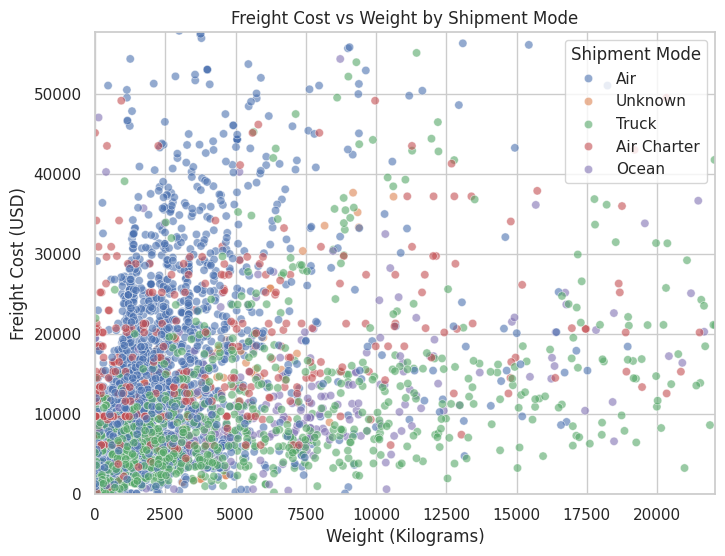

In [ ]:
# Chart 13 - Scatter — Freight Cost vs Weight (Numerical–Numerical) [Bivariate]

# Convert 'Weight (Kilograms)' to numeric, coercing errors
df['Weight (Kilograms)'] = pd.to_numeric(df['Weight (Kilograms)'], errors='coerce')

# Drop rows with missing 'Freight Cost (USD)' for plotting
df_plot = df.dropna(subset=['Freight Cost (USD)', 'Weight (Kilograms)']).copy()

plt.figure(figsize=(8,6))
sns.scatterplot(x='Weight (Kilograms)', y='Freight Cost (USD)', hue='Shipment Mode', data=df_plot, alpha=0.6)
plt.title("Freight Cost vs Weight by Shipment Mode")
plt.xlim(0, df_plot['Weight (Kilograms)'].quantile(0.98))
plt.ylim(0, df_plot['Freight Cost (USD)'].quantile(0.98))
plt.show()

**Why this chart?**

Scatterplots show the relationship between two numeric variables. Adding shipment mode color reveals how weight impacts cost across modes.

**Insight(s):**

Freight cost increases with weight (expected). Air tends to cost more per kg, while Ocean/Truck are cheaper.

**Business impact:**

Positive: Supports mode selection policies based on shipment weight.

Risk: Overuse of Air for heavy shipments drives cost inefficiency.

# Chart 14 - Heatmap — Correlation of Key Variables [Multivariate]

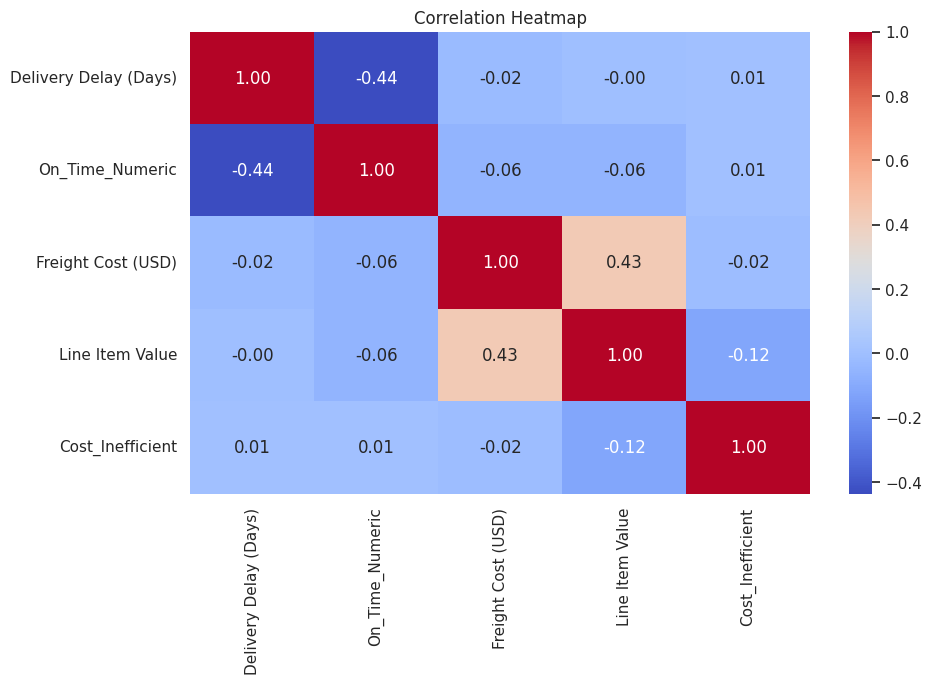

Correlation with On_Time_Numeric:
 Delivery Delay (Days)   -0.44
Freight Cost (USD)      -0.06
Line Item Value         -0.06
Cost_Inefficient         0.01
Name: On_Time_Numeric, dtype: float64


In [ ]:
corr_cols = ['Delivery Delay (Days)','On_Time_Numeric','Freight Cost (USD)','Line Item Value','Cost_Inefficient']
plt.figure(figsize=(10,6))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

print("Correlation with On_Time_Numeric:\n", df[corr_cols].corr()['On_Time_Numeric'].drop('On_Time_Numeric').round(2).sort_values())


**Why this chart?**

A heatmap provides a single-view of numeric correlations to guide root-cause focus.

**Insight(s):**

Delay is negatively related to On_Time (expected). Cost_Inefficient often relates to higher freight and lower value.

**Business impact:**

Positive: Informs feature selection for predictive models and process improvement priorities.

Risk: Ignoring key correlates leaves systemic issues unsolved.

# Chart 15 - Grouped Bar — On-Time by Country × Shipment Mode (Top 12 countries) [Multivariate]

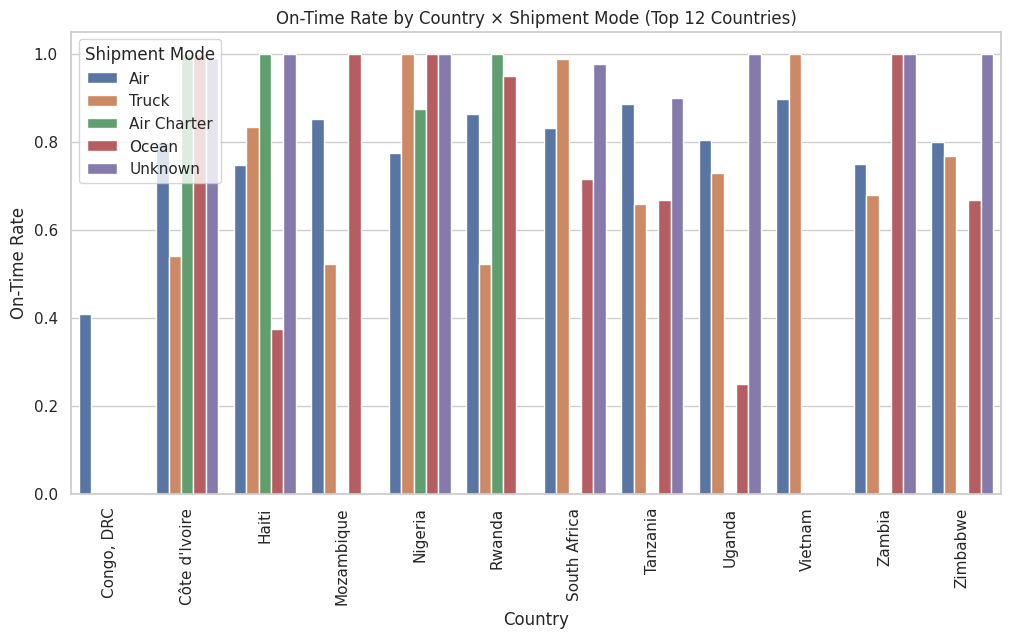

Country×Mode on-time (mean):
 Shipment Mode   Air  Air Charter  Ocean  Truck  Unknown
Country                                                
Congo, DRC     0.41          NaN    NaN   0.00      NaN
Côte d'Ivoire  0.80         1.00   1.00   0.54     0.99
Haiti          0.75         1.00   0.37   0.83     1.00
Mozambique     0.85          NaN   1.00   0.52      NaN
Nigeria        0.78         0.88   1.00   1.00     1.00
Rwanda         0.86         1.00   0.95   0.52      NaN
South Africa   0.83          NaN   0.72   0.99     0.98
Tanzania       0.89          NaN   0.67   0.66     0.90
Uganda         0.80          NaN   0.25   0.73     1.00
Vietnam        0.90          NaN    NaN   1.00      NaN
Zambia         0.75          NaN   1.00   0.68     1.00
Zimbabwe       0.80         0.00   0.67   0.77     1.00


In [ ]:
country_mode = df.groupby(['Country','Shipment Mode'])['On_Time_Numeric'].mean().reset_index()
top_countries = df['Country'].value_counts().head(12).index
cm_sub = country_mode[country_mode['Country'].isin(top_countries)]

plt.figure(figsize=(12,6))
sns.barplot(x='Country', y='On_Time_Numeric', hue='Shipment Mode', data=cm_sub)
plt.title("On-Time Rate by Country × Shipment Mode (Top 12 Countries)")
plt.xticks(rotation=90)
plt.ylabel("On-Time Rate")
plt.show()

cm_summary = cm_sub.pivot_table(index='Country', columns='Shipment Mode', values='On_Time_Numeric', aggfunc='mean')
print("Country×Mode on-time (mean):\n", cm_summary.round(2))


**Why this chart?**

Shows two dimensions together—geography and mode—for nuanced bottlenecks.

**Insight(s):**

Some countries perform poorly overall, but specific modes (e.g., Air) still deliver well there.

**Business impact:**

Positive: Enables country+mode playbooks (e.g., “In Country X, prefer Air”).

Risk: Blanket policies per country can miss nuance.

# Chart 16 - Line — Seasonality: Monthly Freight Cost & On-Time [Multivariate]

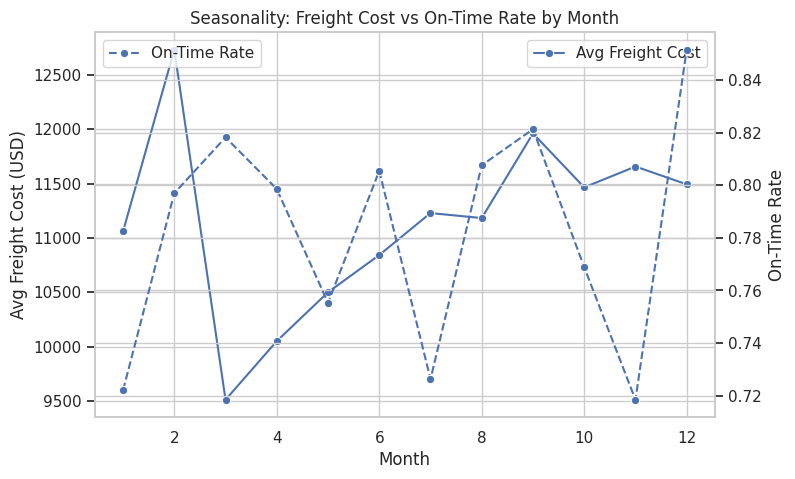

Monthly averages:
     Month  Freight Cost (USD)  On_Time_Numeric
0       1           11061.245            0.722
1       2           12733.317            0.797
2       3            9511.359            0.818
3       4           10051.073            0.799
4       5           10500.987            0.755
5       6           10843.684            0.805
6       7           11229.911            0.726
7       8           11183.893            0.808
8       9           11963.077            0.821
9      10           11466.514            0.769
10     11           11658.135            0.718
11     12           11494.632            0.851


In [ ]:
monthly = df.groupby(df['Scheduled Delivery Date'].dt.month)[['Freight Cost (USD)','On_Time_Numeric']].mean().reset_index()
monthly.columns = ['Month','Freight Cost (USD)','On_Time_Numeric']

fig, ax1 = plt.subplots(figsize=(8,5))
sns.lineplot(x='Month', y='Freight Cost (USD)', data=monthly, marker="o", ax=ax1, label="Avg Freight Cost")

ax2 = ax1.twinx()
sns.lineplot(x='Month', y='On_Time_Numeric', data=monthly, marker="o", ax=ax2, label="On-Time Rate", linestyle='--')

ax1.set_ylabel("Avg Freight Cost (USD)")
ax2.set_ylabel("On-Time Rate")
plt.title("Seasonality: Freight Cost vs On-Time Rate by Month")
plt.show()

print("Monthly averages:\n", monthly.round(3))


**Why this chart?**

Line charts reveal time trends; a dual-axis compares cost vs punctuality across months.

**Insight(s):**

Costs peak in some months while on-time dips during seasonal congestion.

**Business impact:**

Positive: Supports seasonal capacity & pricing planning.

Risk: Unmanaged peaks drive delays and surcharges.

# Chart 17 - Pairplot — Key Features Colored by On-Time [Multivariate]

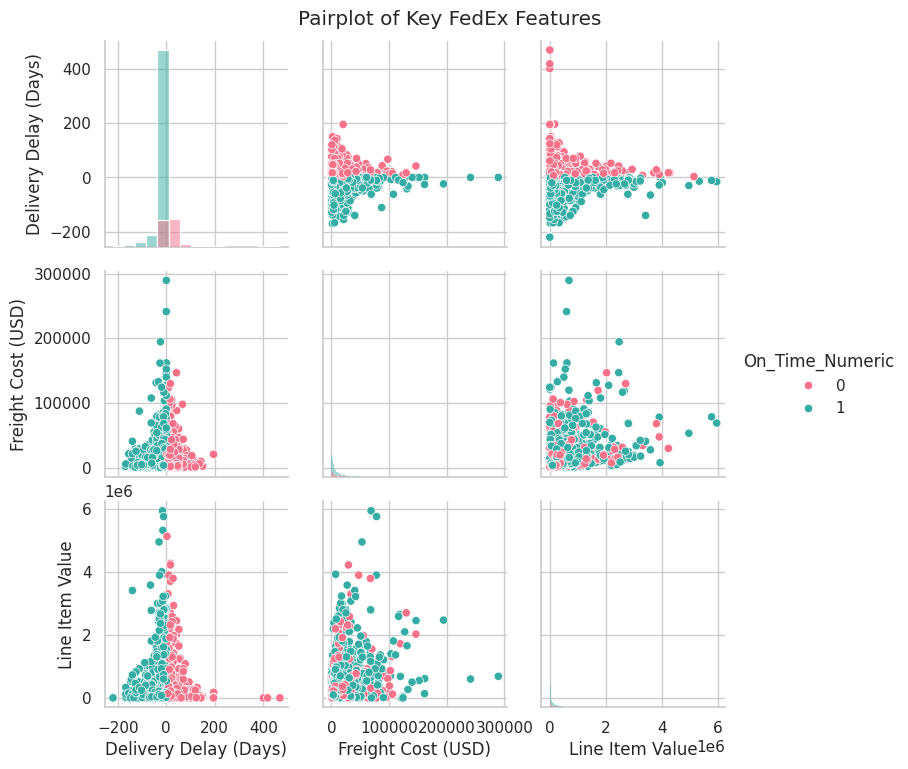

In [ ]:
sns.pairplot(
    df[['Delivery Delay (Days)', 'Freight Cost (USD)', 'Line Item Value', 'On_Time_Numeric']],
    hue="On_Time_Numeric", palette="husl", diag_kind="hist"
)
plt.suptitle("Pairplot of Key FedEx Features", y=1.02)
plt.show()


**Why this chart?**

A pairplot visualizes pairwise relationships and distributions across multiple features, revealing clusters/overlaps.

**Insight(s):**

On-time vs late shipments overlap significantly; no single variable explains delays. Outliers in freight vs value confirm inefficiencies.

**Business impact:**

Positive: Confirms the need for multi-factor optimization and predictive models.

Risk: Simple, single-metric fixes won’t move the needle.

# Combination Plot 1 — Monthly Freight Cost (Bar) + On-Time Rate (Line)

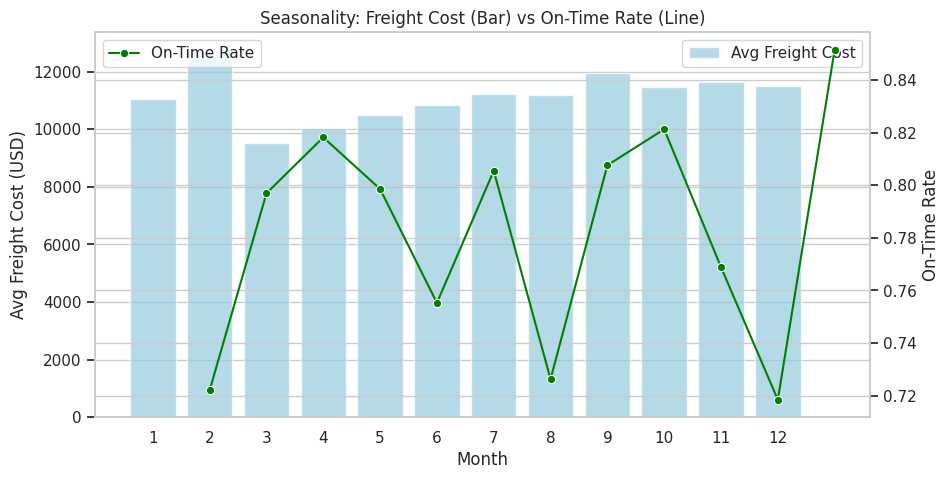

Monthly averages:
     Month  Avg Freight Cost  On_Time Rate
0       1         11061.245         0.722
1       2         12733.317         0.797
2       3          9511.359         0.818
3       4         10051.073         0.799
4       5         10500.987         0.755
5       6         10843.684         0.805
6       7         11229.911         0.726
7       8         11183.893         0.808
8       9         11963.077         0.821
9      10         11466.514         0.769
10     11         11658.135         0.718
11     12         11494.632         0.851


In [ ]:
# Group by month from Scheduled Delivery Date
monthly = df.groupby(df['Scheduled Delivery Date'].dt.month)[['Freight Cost (USD)','On_Time_Numeric']].mean().reset_index()
monthly.columns = ['Month','Avg Freight Cost','On_Time Rate']

fig, ax1 = plt.subplots(figsize=(10,5))

# Barplot for Avg Freight Cost
sns.barplot(x='Month', y='Avg Freight Cost', data=monthly, ax=ax1, color="skyblue", alpha=0.7, label="Avg Freight Cost")
ax1.set_ylabel("Avg Freight Cost (USD)")
ax1.set_xlabel("Month")

# Secondary axis for On-Time Rate
ax2 = ax1.twinx()
sns.lineplot(x='Month', y='On_Time Rate', data=monthly, ax=ax2, marker="o", color="green", label="On-Time Rate")
ax2.set_ylabel("On-Time Rate")

plt.title("Seasonality: Freight Cost (Bar) vs On-Time Rate (Line)")
plt.show()

print("Monthly averages:\n", monthly.round(3))


**Why this chart?**

This combination plot shows two metrics together: monthly average Freight Cost (bar) and average On-Time Rate (line). It’s ideal for identifying seasonal patterns where cost and punctuality interact.

**Insight(s):**

Freight costs peak in certain months (seasonal demand).

On-time performance often dips in those same months, suggesting congestion or capacity stress.

**Business impact:**

Positive: Helps plan dynamic pricing and capacity expansion in peak months.

Risk: If peak costs coincide with late deliveries, customers may churn to competitors.

# Combination Plot 2 — Freight Cost vs Weight (Scatter + Regression Line)

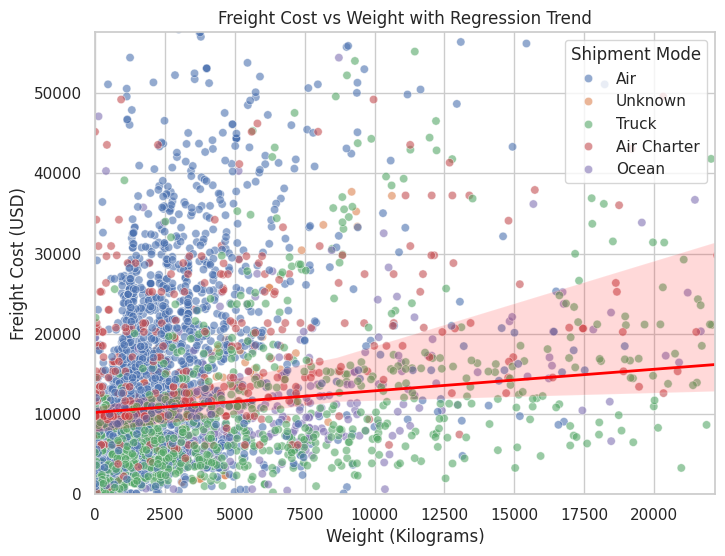

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Weight (Kilograms)', y='Freight Cost (USD)', hue='Shipment Mode', data=df, alpha=0.6)
sns.regplot(x='Weight (Kilograms)', y='Freight Cost (USD)', data=df, scatter=False, color="red", line_kws={"linewidth":2})
plt.title("Freight Cost vs Weight with Regression Trend")
plt.xlim(0, df['Weight (Kilograms)'].quantile(0.98))
plt.ylim(0, df['Freight Cost (USD)'].quantile(0.98))
plt.show()


**Why this chart?**

Scatterplots show the raw relationship between two numeric variables (weight vs cost). Adding a regression line reveals the overall trend, even if data points are noisy.

**Insight(s):**

As weight increases, freight cost also increases (expected trend).

Air shipments cluster higher (costlier per kg), while Ocean/Truck cluster lower.

A few outliers deviate from the trend (inefficient pricing).

**Business impact:**

Positive: Confirms expected weight–cost dynamics; supports mode selection policies.

Risk: Outliers suggest billing/contract anomalies; if ignored, they erode profits.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

**Solution to Improve FedEx Logistics Performance**

*	Optimize Shipment Mode Selection
*	Improve Vendor & Country Performance
*	Reduce Cost Inefficiency
*	Strengthen Risk Management (Insurance).
*	Address Seasonal Bottlenecks
*	Last-Mile Delivery Improvements
*	Data-Driven Performance Monitoring




# **Conclusion**

* Most shipments are delivered on time, but certain countries and modes      face recurring delays.

* Ocean freight shows the highest variability, while Air/Truck are more reliable but costly.

* Some vendors underperform consistently, requiring better monitoring and accountability.

* Cost inefficiency exists where freight cost exceeds item value, highlighting planning issues.

* Insurance adoption is uneven across countries, exposing risk in some regions.

* Seasonal peaks increase costs and reduce on-time rates, indicating congestion challenges.

* Logistics performance is multi-factorial — no single variable explains delays; combined actions are needed.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***